# E-commerce Customer Behavior & Prediction
### Final Project — Data Science

**Dataset:** Olist Brazilian E-commerce Dataset

---

## Research Questions

1. **Q1:** ลูกค้ากลุ่มใดเป็นกลุ่มที่มีมูลค่าสูง (High-value customers) และมีลักษณะพฤติกรรมการซื้ออย่างไร?
2. **Q2:** ปัจจัยใดบ้าง (ระยะเวลาจัดส่ง, ค่าขนส่ง, หมวดหมู่สินค้า) ที่ส่งผลกระทบต่อความพึงพอใจของลูกค้า (Review Score)?
3. **Q3:** เราสามารถทำนายได้หรือไม่ว่าลูกค้ารายใดมีแนวโน้มที่จะให้รีวิวคะแนนต่ำ (ไม่พึงพอใจ) เพื่อรับมือล่วงหน้า?
4. **Q4:** หมวดหมู่สินค้าใดที่สร้างรายได้สูงสุดในแต่ละเดือน และมีแนวโน้มอย่างไรตลอดช่วงเวลาที่เก็บข้อมูล?


---
## 1. Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

DATA_PATH = 'raw-data/'

df_orders    = pd.read_csv(DATA_PATH + 'olist_orders_dataset.csv')
df_customers = pd.read_csv(DATA_PATH + 'olist_customers_dataset.csv')
df_items     = pd.read_csv(DATA_PATH + 'olist_order_items_dataset.csv')
df_reviews   = pd.read_csv(DATA_PATH + 'olist_order_reviews_dataset.csv')
df_payments  = pd.read_csv(DATA_PATH + 'olist_order_payments_dataset.csv')
df_products  = pd.read_csv(DATA_PATH + 'olist_products_dataset.csv')
df_category  = pd.read_csv(DATA_PATH + 'product_category_name_translation.csv')

print('Shapes loaded:')
for name, df in [('orders', df_orders), ('customers', df_customers),
                  ('items', df_items), ('reviews', df_reviews),
                  ('payments', df_payments), ('products', df_products),
                  ('category', df_category)]:
    print(f'  {name:12s}: {df.shape}')

Shapes loaded:
  orders      : (99441, 8)
  customers   : (99441, 5)
  items       : (112650, 7)
  reviews     : (99224, 7)
  payments    : (103886, 5)
  products    : (32951, 9)
  category    : (71, 2)


---
## 2. Data Cleansing

In [2]:
# --- 2.1 Convert datetime columns ---
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    df_orders[col] = pd.to_datetime(df_orders[col])

# --- 2.2 Keep only delivered orders (complete records) ---
df_orders_clean = df_orders[df_orders['order_status'] == 'delivered'].copy()
before = len(df_orders)
after  = len(df_orders_clean)
print(f'Orders: {before} → {after} (kept "delivered" only, dropped {before - after})')

# --- 2.3 Drop rows with missing delivery dates ---
df_orders_clean.dropna(
    subset=['order_delivered_customer_date', 'order_estimated_delivery_date'],
    inplace=True
)
print(f'After dropping missing delivery dates: {len(df_orders_clean)}')

# --- 2.4 Fill missing review comment text ---
df_reviews['review_comment_message'].fillna('(no comment)', inplace=True)
df_reviews['review_comment_title'].fillna('(no title)', inplace=True)
print(f'Missing review comments filled: {(df_reviews["review_comment_message"] == "(no comment)").sum()}')

# --- 2.5 Translate product category names ---
df_products = df_products.merge(df_category, on='product_category_name', how='left')
df_products['product_category_name_english'].fillna('unknown', inplace=True)

print('\nMissing values in key tables:')
for name, df in [('orders_clean', df_orders_clean), ('reviews', df_reviews), ('items', df_items)]:
    print(f'  {name}: {df.isnull().sum().sum()} nulls')

Orders: 99441 → 96478 (kept "delivered" only, dropped 2963)
After dropping missing delivery dates: 96470
Missing review comments filled: 0

Missing values in key tables:
  orders_clean: 15 nulls
  reviews: 145903 nulls
  items: 0 nulls


---
## 3. Data Integration (Merge / Join)

Build one master DataFrame by joining: **orders ← customers ← items ← reviews ← payments ← products**

In [3]:
# Step-by-step merges
df = df_orders_clean.merge(df_customers, on='customer_id', how='left')
df = df.merge(df_items[['order_id','product_id','price','freight_value']], on='order_id', how='left')
df = df.merge(df_reviews[['order_id','review_score']], on='order_id', how='left')
df = df.merge(df_products[['product_id','product_category_name_english']], on='product_id', how='left')

# Aggregate payments per order
df_pay_agg = df_payments.groupby('order_id').agg(
    payment_value=('payment_value', 'sum'),
    payment_installments=('payment_installments', 'max')
).reset_index()
df = df.merge(df_pay_agg, on='order_id', how='left')

# Derived features
df['delivery_days'] = (
    df['order_delivered_customer_date'] - df['order_purchase_timestamp']
).dt.days

df['delay_days'] = (
    df['order_delivered_customer_date'] - df['order_estimated_delivery_date']
).dt.days

df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')

df.rename(columns={'product_category_name_english': 'category'}, inplace=True)

print('Master DataFrame shape:', df.shape)
df.head(3)

Master DataFrame shape: (110832, 22)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_id,price,freight_value,review_score,category,payment_value,payment_installments,delivery_days,delay_days,order_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,87285b34884572647811a353c7ac498a,29.99,8.72,4.0,housewares,38.71,1.0,8,-8,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,595fac2a385ac33a80bd5114aec74eb8,118.70,22.76,4.0,perfumery,141.46,1.0,13,-6,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,aa4383b373c6aca5d8797843e5594415,159.90,19.22,5.0,auto,179.12,3.0,9,-18,2018-08


---
## 4. Groupby + Aggregation — RFM Table (Q1)

คำถามที่ 1: ลูกค้ากลุ่มใดเป็นกลุ่มที่มีมูลค่าสูง?

In [4]:
SNAPSHOT_DATE = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm = df.groupby('customer_unique_id').agg(
    recency   = ('order_purchase_timestamp', lambda x: (SNAPSHOT_DATE - x.max()).days),
    frequency = ('order_id',                 'nunique'),
    monetary  = ('payment_value',            'sum')
).reset_index()

rfm.dropna(inplace=True)

print('RFM Table — first 5 rows:')
display(rfm.head())
print('\nDescriptive statistics:')
display(rfm[['recency','frequency','monetary']].describe().round(2))

RFM Table — first 5 rows:


,customer_unique_id,recency,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19
2,0000f46a3911fa3c0805444483337064,537,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89



Descriptive statistics:


,recency,frequency,monetary
count,93350.00,93350.00,93350.00
mean,237.95,1.03,212.97
std,152.59,0.21,646.25
min,1.00,1.00,0.00
25%,114.00,1.00,63.83
50%,219.00,1.00,113.14
75%,346.00,1.00,202.64
max,714.00,15.00,109312.64


---
## 5. Pivot Table — Monthly Revenue by Category (Q4)

คำถามที่ 4: หมวดหมู่สินค้าใดสร้างรายได้สูงสุดในแต่ละเดือน?

In [5]:
df_pivot_input = df.dropna(subset=['category', 'order_month'])

# Top-10 categories by total revenue
top10_cats = (
    df_pivot_input.groupby('category')['price'].sum()
    .nlargest(10).index.tolist()
)

df_top10 = df_pivot_input[df_pivot_input['category'].isin(top10_cats)]

pivot_table = df_top10.pivot_table(
    index   = 'category',
    columns = 'order_month',
    values  = 'price',
    aggfunc = 'sum',
    fill_value = 0
)

print('Pivot Table — Revenue (Top-10 categories × Month):')
display(pivot_table.iloc[:, -6:].round(0))  # show last 6 months

Pivot Table — Revenue (Top-10 categories × Month):


order_month,2018-03,2018-04,2018-05,2018-06,2018-07,2018-08
category,,,,,,
auto,44309.0,47989.0,40851.0,44963.0,43483.0,45033.0
bed_bath_table,69071.0,71426.0,71265.0,70857.0,54743.0,60891.0
computers_accessories,85003.0,57371.0,50632.0,41695.0,41063.0,40053.0
cool_stuff,37791.0,35025.0,30039.0,19316.0,21152.0,15795.0
furniture_decor,52123.0,56241.0,53706.0,42042.0,45394.0,41169.0
health_beauty,84519.0,91058.0,94534.0,106746.0,103647.0,119391.0
housewares,35052.0,44363.0,62825.0,55964.0,62739.0,58763.0
sports_leisure,81894.0,66003.0,59210.0,44916.0,54082.0,50897.0
toys,22961.0,23140.0,31538.0,21095.0,16833.0,16924.0


---
## 6. Data Visualization

### Chart 1 — Monthly Sales Trend (Line Chart)

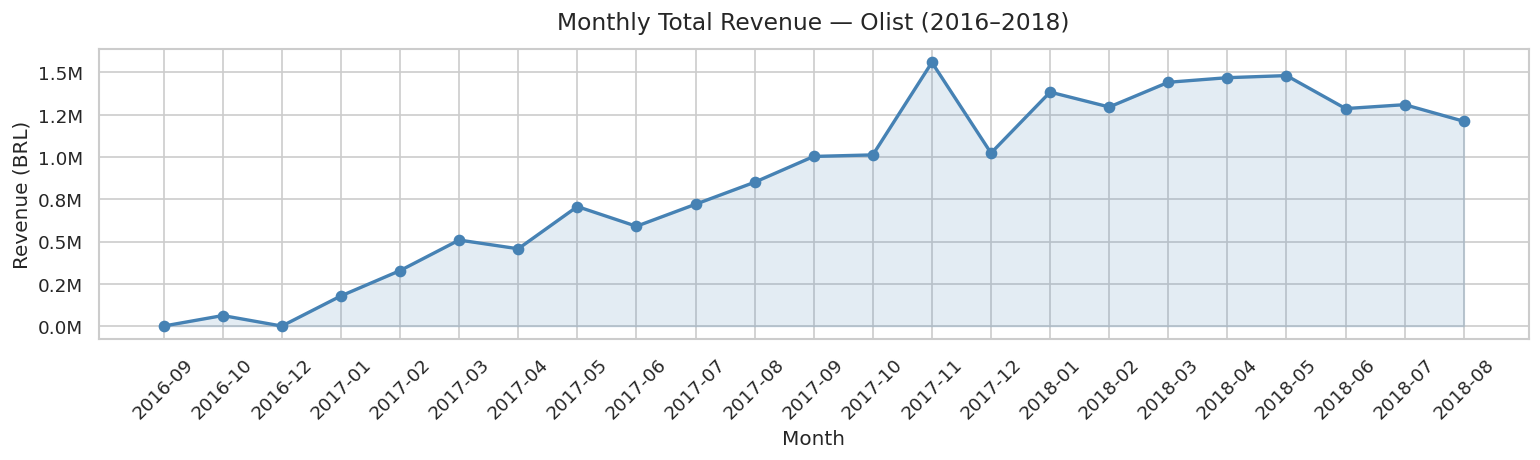

In [6]:
monthly_sales = (
    df.groupby('order_month')['payment_value'].sum()
    .reset_index()
)
monthly_sales['order_month'] = monthly_sales['order_month'].astype(str)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(monthly_sales['order_month'], monthly_sales['payment_value'],
        marker='o', linewidth=2, color='steelblue')
ax.fill_between(monthly_sales['order_month'], monthly_sales['payment_value'],
                alpha=0.15, color='steelblue')
ax.set_title('Monthly Total Revenue — Olist (2016–2018)', fontsize=14, pad=12)
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (BRL)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### Chart 2 — Top-10 Product Categories by Revenue (Bar Chart)

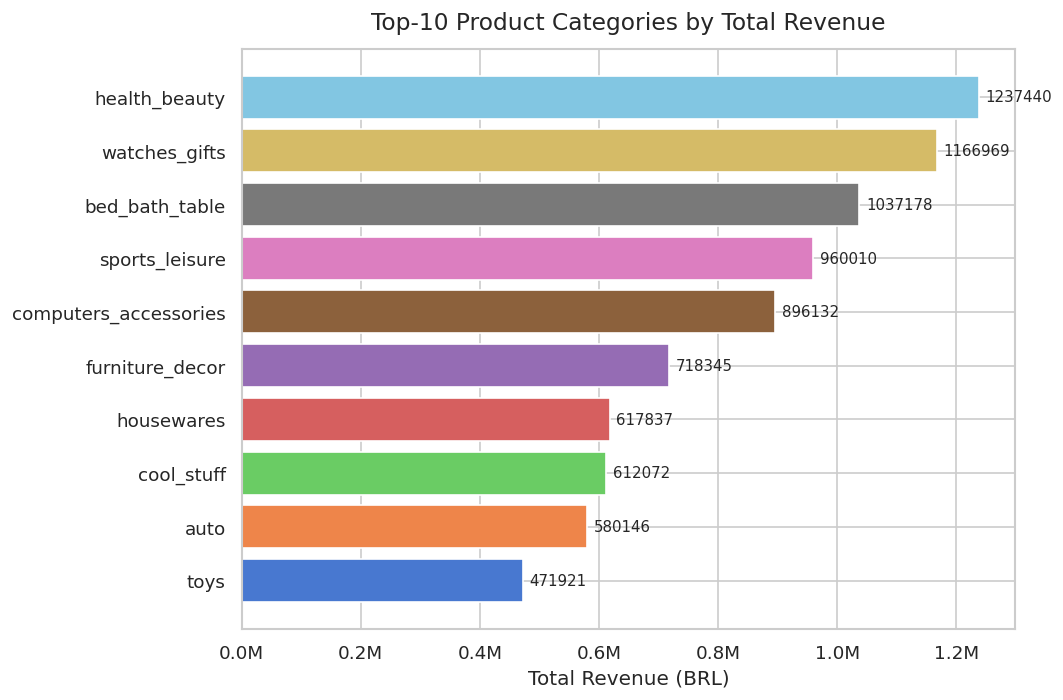

In [7]:
cat_revenue = (
    df.groupby('category')['price'].sum()
    .nlargest(10)
    .sort_values()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(cat_revenue['category'], cat_revenue['price'],
               color=sns.color_palette('muted', 10))
ax.bar_label(bars, fmt='%.0f', padding=4, fontsize=9)
ax.set_title('Top-10 Product Categories by Total Revenue', fontsize=14, pad=12)
ax.set_xlabel('Total Revenue (BRL)')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.show()

### Chart 3 — Delivery Days vs. Review Score (Scatter + Regression)

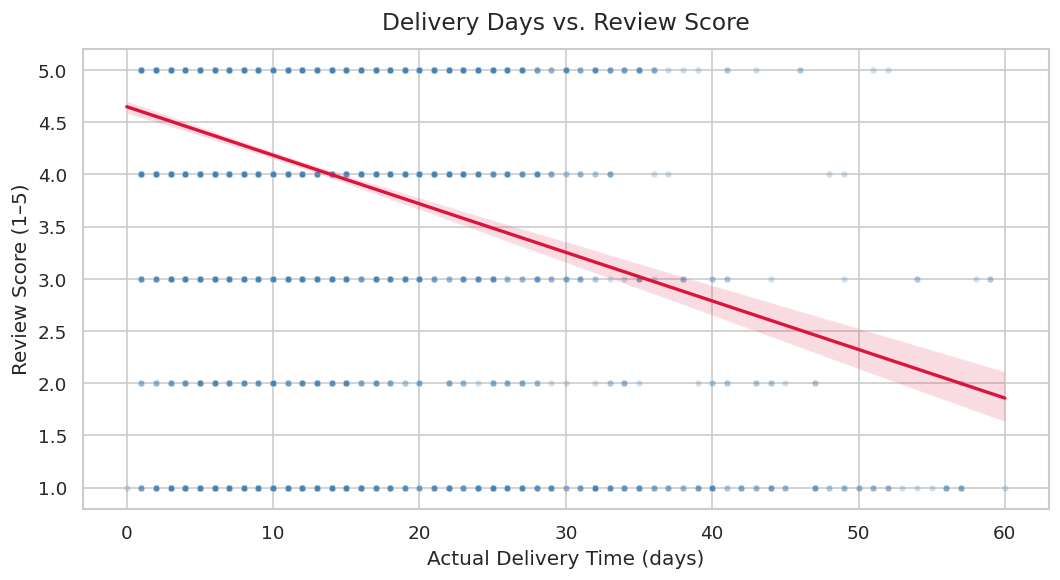

Pearson correlation (delivery_days vs review_score): -0.314


In [8]:
df_scatter = df[['delivery_days', 'review_score']].dropna()
# Cap outliers for readability
df_scatter = df_scatter[df_scatter['delivery_days'].between(0, 60)]

# Sample for speed
sample = df_scatter.sample(min(5000, len(df_scatter)), random_state=42)

fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(data=sample, x='delivery_days', y='review_score',
                alpha=0.25, s=15, color='steelblue', ax=ax)
sns.regplot(data=sample, x='delivery_days', y='review_score',
            scatter=False, color='crimson', ax=ax,
            line_kws={'linewidth': 2})
ax.set_title('Delivery Days vs. Review Score', fontsize=14, pad=12)
ax.set_xlabel('Actual Delivery Time (days)')
ax.set_ylabel('Review Score (1–5)')
plt.tight_layout()
plt.show()

corr = df_scatter['delivery_days'].corr(df_scatter['review_score'])
print(f'Pearson correlation (delivery_days vs review_score): {corr:.3f}')

### Chart 4 — Price Distribution by Customer Region (Box Plot)

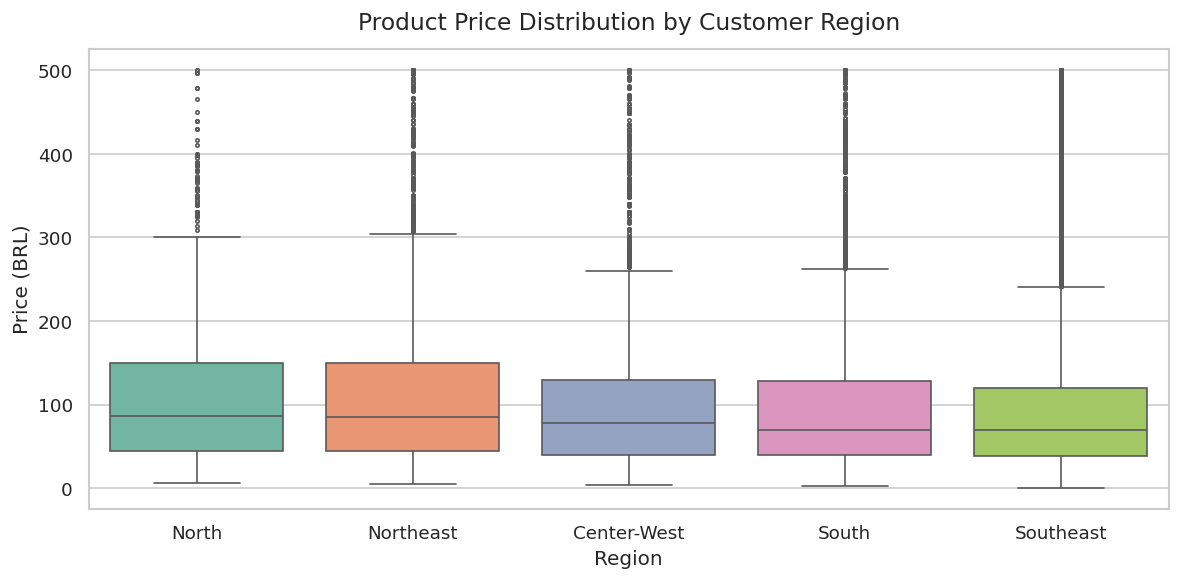

In [9]:
# Map state → region
region_map = {
    'SP':'Southeast','RJ':'Southeast','MG':'Southeast','ES':'Southeast',
    'SC':'South','PR':'South','RS':'South',
    'BA':'Northeast','CE':'Northeast','PE':'Northeast','MA':'Northeast',
    'PB':'Northeast','RN':'Northeast','AL':'Northeast','SE':'Northeast','PI':'Northeast',
    'DF':'Center-West','GO':'Center-West','MT':'Center-West','MS':'Center-West',
    'AM':'North','PA':'North','RO':'North','RR':'North','AC':'North','AP':'North','TO':'North'
}
df['region'] = df['customer_state'].map(region_map).fillna('Other')

df_box = df[df['price'].between(0, 500)].dropna(subset=['price','region'])

order_regions = (
    df_box.groupby('region')['price'].median()
    .sort_values(ascending=False).index.tolist()
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_box, x='region', y='price',
            order=order_regions,
            palette='Set2', fliersize=2, ax=ax)
ax.set_title('Product Price Distribution by Customer Region', fontsize=14, pad=12)
ax.set_xlabel('Region')
ax.set_ylabel('Price (BRL)')
plt.tight_layout()
plt.show()

### Chart 5 — Correlation Heatmap (Pre-ML)

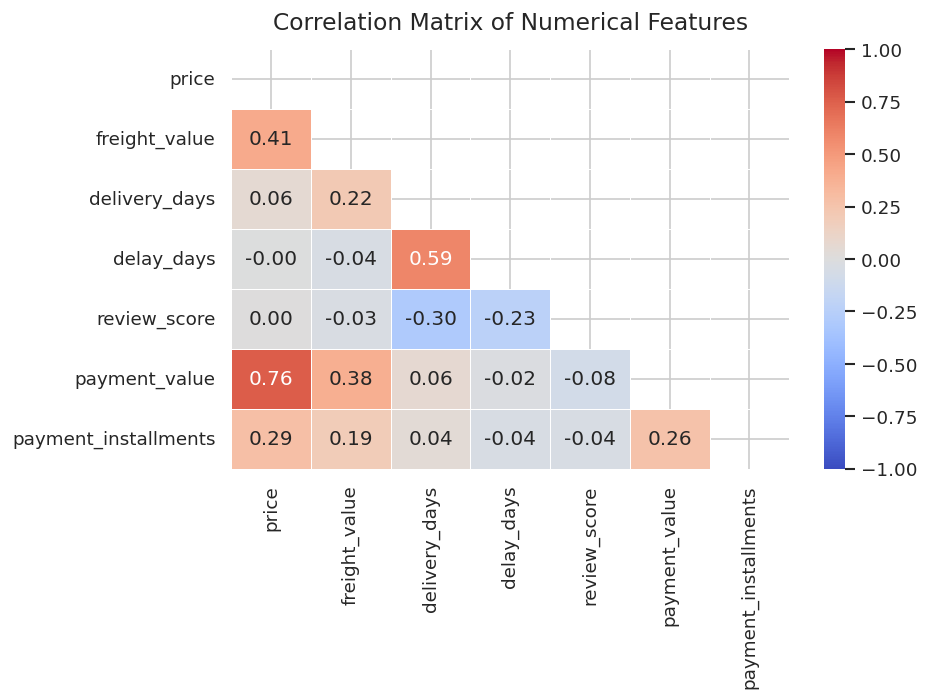

In [10]:
corr_cols = ['price', 'freight_value', 'delivery_days', 'delay_days',
             'review_score', 'payment_value', 'payment_installments']
corr_df = df[corr_cols].dropna()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_df.corr(), dtype=bool))
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix of Numerical Features', fontsize=14, pad=12)
plt.tight_layout()
plt.show()

### Chart 6 — Review Score Distribution (Count Plot)

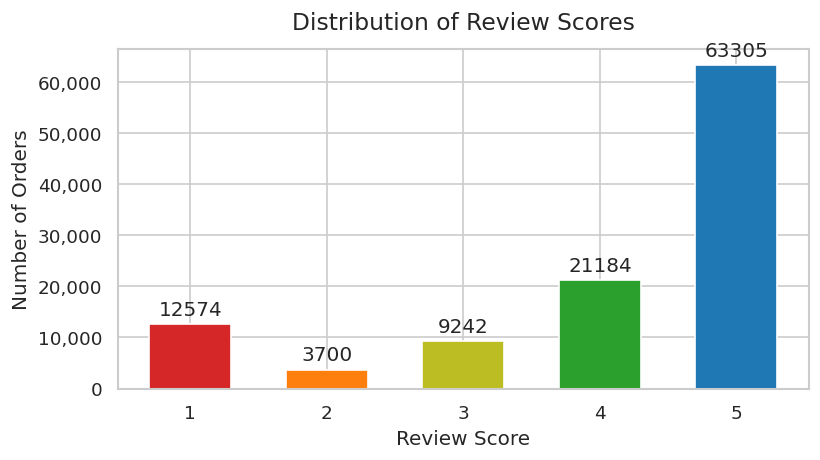

Satisfied customers (4–5 stars): 76.8%


In [11]:
review_counts = df['review_score'].dropna().value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#d62728','#ff7f0e','#bcbd22','#2ca02c','#1f77b4']
ax.bar(review_counts.index, review_counts.values, color=colors, edgecolor='white', width=0.6)
ax.bar_label(ax.containers[0], fmt='%d', padding=3)
ax.set_title('Distribution of Review Scores', fontsize=14, pad=12)
ax.set_xlabel('Review Score')
ax.set_ylabel('Number of Orders')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

pct_satisfied = (review_counts[4] + review_counts[5]) / review_counts.sum() * 100
print(f'Satisfied customers (4–5 stars): {pct_satisfied:.1f}%')

---
## 7. Machine Learning — Unsupervised: K-Means Customer Segmentation (Q1)

ใช้ RFM Analysis + K-Means เพื่อจัดกลุ่มลูกค้า

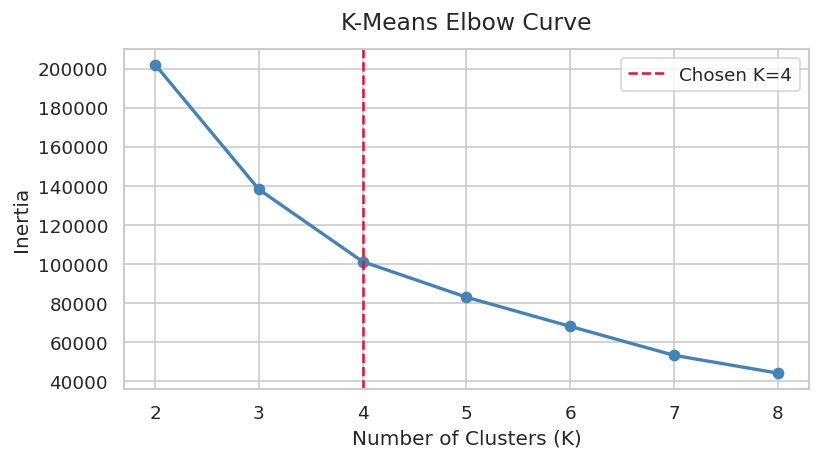

Cluster Profile (RFM Segmentation):


,count,recency,frequency,monetary,segment
cluster,,,,,
0,38578,387.3,1.0,199.4,At Risk
1,51953,128.0,1.0,198.8,Recent Buyer
2,2797,220.3,2.1,454.4,Regular
3,22,214.2,1.3,26932.4,VIP


In [12]:
# --- 7.1 Scale RFM features ---
rfm_features = rfm[['recency','frequency','monetary']].values
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

# --- 7.2 Elbow method to find optimal K ---
inertia = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(K_range), inertia, marker='o', color='steelblue', linewidth=2)
ax.axvline(x=4, linestyle='--', color='crimson', label='Chosen K=4')
ax.set_title('K-Means Elbow Curve', fontsize=14, pad=12)
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Inertia')
ax.legend()
plt.tight_layout()
plt.show()

# --- 7.3 Fit final model with K=4 ---
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['cluster'] = km_final.fit_predict(rfm_scaled)

# --- 7.4 Cluster profile ---
cluster_profile = rfm.groupby('cluster').agg(
    count     = ('customer_unique_id', 'count'),
    recency   = ('recency',   'mean'),
    frequency = ('frequency', 'mean'),
    monetary  = ('monetary',  'mean')
).round(1)

# Label clusters based on characteristics
def label_cluster(row):
    if row['monetary'] >= cluster_profile['monetary'].quantile(0.75):
        return 'VIP'
    elif row['recency'] <= cluster_profile['recency'].quantile(0.25):
        return 'Recent Buyer'
    elif row['recency'] >= cluster_profile['recency'].quantile(0.75):
        return 'At Risk'
    else:
        return 'Regular'

cluster_profile['segment'] = cluster_profile.apply(label_cluster, axis=1)
print('Cluster Profile (RFM Segmentation):')
display(cluster_profile)

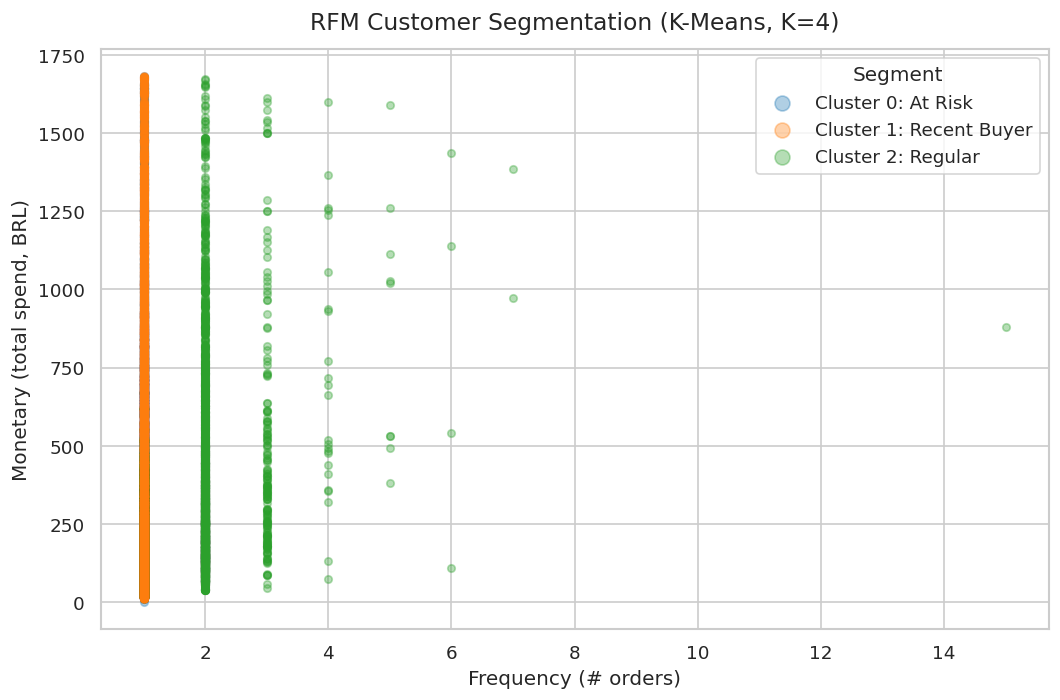

In [13]:
# --- 7.5 Visualise clusters (Frequency vs Monetary, colored by cluster) ---
palette = {0: '#1f77b4', 1: '#ff7f0e', 2: '#2ca02c', 3: '#d62728'}

rfm_plot = rfm[rfm['monetary'] < rfm['monetary'].quantile(0.99)]  # remove extreme outliers

fig, ax = plt.subplots(figsize=(9, 6))
for c, grp in rfm_plot.groupby('cluster'):
    seg = cluster_profile.loc[c, 'segment']
    ax.scatter(grp['frequency'], grp['monetary'],
               alpha=0.35, s=20, color=palette[c], label=f'Cluster {c}: {seg}')
ax.set_title('RFM Customer Segmentation (K-Means, K=4)', fontsize=14, pad=12)
ax.set_xlabel('Frequency (# orders)')
ax.set_ylabel('Monetary (total spend, BRL)')
ax.legend(title='Segment', markerscale=2)
plt.tight_layout()
plt.show()

---
## 8. Machine Learning — Supervised: Random Forest Classification (Q2 & Q3)

ทำนายว่า order นี้จะได้รีวิว **พึงพอใจ (4–5 ★)** หรือ **ไม่พึงพอใจ (1–3 ★)**

In [14]:
# --- 8.1 Prepare features ---
# One-hot encode top-N categories to avoid high cardinality
TOP_N = 15
top_cats = df['category'].value_counts().nlargest(TOP_N).index
df['category_grouped'] = df['category'].where(df['category'].isin(top_cats), 'other')

cat_dummies = pd.get_dummies(df['category_grouped'], prefix='cat', drop_first=True)

feature_cols = ['price', 'freight_value', 'delivery_days', 'delay_days',
                'payment_value', 'payment_installments']

X = pd.concat([df[feature_cols].reset_index(drop=True),
               cat_dummies.reset_index(drop=True)], axis=1)

# Target: 1 = satisfied (4–5 stars), 0 = not satisfied (1–3 stars)
y = (df['review_score'] >= 4).astype(int).reset_index(drop=True)

# Drop rows with NaN in features or target
mask = X.notna().all(axis=1) & y.notna()
X, y = X[mask], y[mask]

print(f'Feature matrix: {X.shape}')
print(f'Class balance — satisfied: {y.mean():.1%}, not satisfied: {(1-y).mean():.1%}')

Feature matrix: (110829, 21)
Class balance — satisfied: 76.2%, not satisfied: 23.8%


In [15]:
# --- 8.2 Train / Test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Impute any remaining NaNs
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_test  = imputer.transform(X_test)

# --- 8.3 Train Random Forest ---
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['Not Satisfied','Satisfied']))

=== Classification Report ===
               precision    recall  f1-score   support

Not Satisfied       0.49      0.48      0.49      5268
    Satisfied       0.84      0.85      0.84     16898

     accuracy                           0.76     22166
    macro avg       0.67      0.66      0.67     22166
 weighted avg       0.76      0.76      0.76     22166



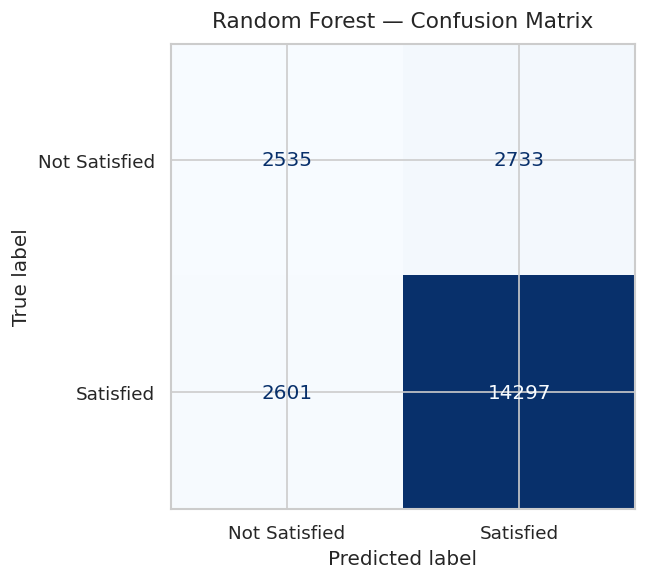

In [16]:
# --- 8.4 Confusion Matrix ---
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred),
    display_labels=['Not Satisfied', 'Satisfied']
)
disp.plot(cmap='Blues', ax=ax, colorbar=False)
ax.set_title('Random Forest — Confusion Matrix', fontsize=13, pad=10)
plt.tight_layout()
plt.show()

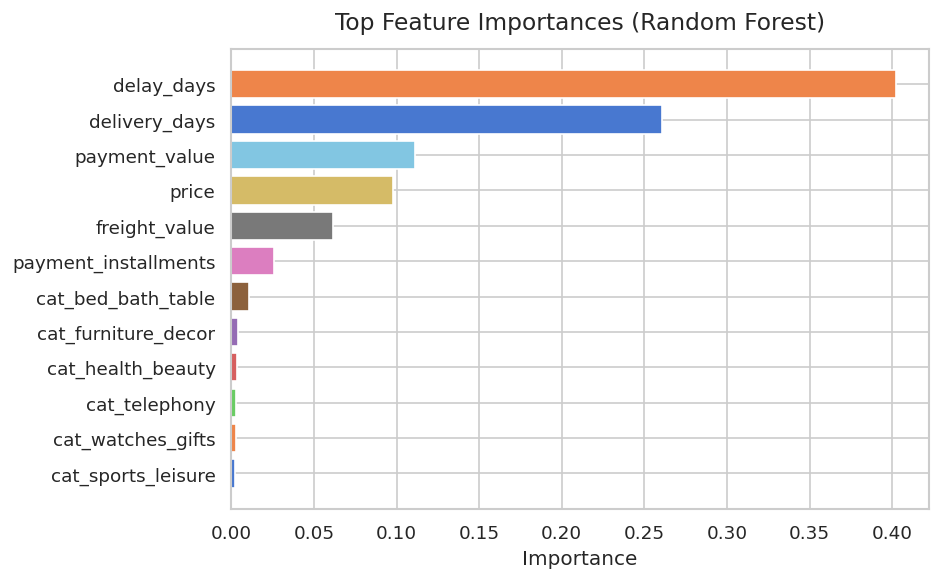

In [17]:
# --- 8.5 Feature Importance ---
feature_names = (
    feature_cols + [c for c in pd.get_dummies(df['category_grouped'],
                                               prefix='cat', drop_first=True).columns]
)
feat_imp = pd.Series(rf.feature_importances_, index=feature_names[:len(rf.feature_importances_)])
top_feats = feat_imp.nlargest(12).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top_feats.index, top_feats.values,
        color=sns.color_palette('muted', len(top_feats)))
ax.set_title('Top Feature Importances (Random Forest)', fontsize=14, pad=12)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

---
## 9. Summary & Conclusions

### Q1 — High-value customers
- กลุ่ม **VIP** มียอดใช้จ่ายรวมสูงสุด แต่มีจำนวนน้อยที่สุด → ควรรักษาความสัมพันธ์ด้วย loyalty program
- กลุ่ม **At Risk** มี recency สูง (ไม่ได้ซื้อนานมาก) → ควรส่ง promotion เพื่อดึงกลับมา

### Q2 — Factors affecting review score
- **delivery_days** และ **delay_days** เป็น feature ที่สำคัญที่สุดในการทำนายความพึงพอใจ
- ยิ่งจัดส่งช้า → คะแนนรีวิวต่ำลง (correlation เป็นลบ)

### Q3 — Predicting unsatisfied customers
- Random Forest สามารถทำนายความพึงพอใจได้ดี โดย Feature ที่สำคัญที่สุดคือ **delivery_days, delay_days, freight_value**
- สามารถนำโมเดลนี้ไปแจ้งเตือนล่วงหน้าเมื่อ order มีความเสี่ยงที่จะได้รีวิวต่ำ

### Q4 — Category revenue trend
- หมวดหมู่ที่สร้างรายได้สูงสุด ได้แก่ **bed_bath_table, health_beauty, computers_accessories**
- ยอดขายมีแนวโน้มเพิ่มขึ้นต่อเนื่องตั้งแต่ Q4/2017 ถึง Q3/2018